# Reproducing the letter-valence headline result

**A guided walkthrough of the analysis, with code, numbers, and figures inline.**

Run this notebook after `python -m src.analyze` to confirm every number in the README and the blog post. The notebook reads the CSVs in `results/` and produces the visualisations in `figures/`. It does not retrain anything — it just summarises what `src.analyze` already wrote.

Expected runtime: 2-3 minutes.

---

**Index:**

1. [Headline numbers](#1-headline)
2. [Permutation test](#2-permutation)
3. [Family ablation](#3-families)
4. [Single-family performance](#4-single-family)
5. [Learning curve (bias-variance)](#5-learning)
6. [Method comparison](#6-methods)
7. [ROC curve](#7-roc)
8. [Word-level correlations](#8-word-level)
9. [Per-feature heatmap](#9-heatmap)
10. [Reproducing any number from scratch](#10-reproduce)

## Setup

Add the repo root to the path and import the modules we need. The rest of the notebook just reads CSVs from `results/` and produces the figures in `figures/`.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path('/tmp/letter-valence-research')  # adjust if your repo is elsewhere
sys.path.insert(0, str(REPO_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RESULTS = REPO_ROOT / 'results'
FIGURES = REPO_ROOT / 'figures'
RESULTS.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({'figure.dpi': 100, 'savefig.dpi': 300, 'axes.spines.top': False, 'axes.spines.right': False})
print(f'Repo root: {REPO_ROOT}')
print(f'Results:   {RESULTS}')
print(f'Figures:   {FIGURES}')
print(f'Result files: {sorted(p.name for p in RESULTS.glob("*"))}')

Repo root: /tmp/letter-valence-research
Results:   /tmp/letter-valence-research/results
Figures:   /tmp/letter-valence-research/figures
Result files: ['SUMMARY.md', 'cv_logistic_regression.csv', 'cv_random_forest.csv', 'cv_ridge.csv', 'family_ablation.csv', 'learning_curve.csv', 'permutation_test.json', 'single_family.csv', 'summary.json', 'word_level_correlations.csv']


## 1. Headline numbers

The single number that appears in the README, the blog post, and the abstract:

In [2]:
import json

with open(RESULTS / 'summary.json') as f:
    summary = json.load(f)

n_a = summary['n_articles']
n_f = summary['n_features']
cd = summary['class_distribution']
maj = summary['baselines']['majority_class']['accuracy']
rand_m = summary['baselines']['stratified_random']['accuracy_mean']
rf = summary['random_forest_5fold']['accuracy_mean']
rf_s = summary['random_forest_5fold']['accuracy_std']
lr = summary['logistic_regression_5fold']['accuracy_mean']
lr_s = summary['logistic_regression_5fold']['accuracy_std']
ridge_a = summary['ridge_5fold']['accuracy_mean']
ridge_s = summary['ridge_5fold']['accuracy_std']
pval = summary['permutation_test']['p_value']
nm = summary['permutation_test']['null_mean']
ns = summary['permutation_test']['null_std']

print('Number of articles:       ', n_a)
print('Number of features:        ', n_f)
print('Class distribution:        ', cd)
print()
print('BASELINES:')
print('  Majority class:          ', round(maj, 4))
print('  Stratified random:       ', round(rand_m, 4))
print()
print('MODELS (5-fold CV):')
print(f'  Random Forest:           {rf:.4f} +/- {rf_s:.4f}   <-- HEADLINE')
print(f'  Logistic Regression:      {lr:.4f} +/- {lr_s:.4f}')
print(f'  Ridge Classifier:        {ridge_a:.4f} +/- {ridge_s:.4f}')
print()
print('PERMUTATION TEST:')
print(f'  p-value:                 {pval:.4f}')
print(f'  null mean +/- std:         {nm:.4f} +/- {ns:.4f}')

Number of articles:        1967
Number of features:         68
Class distribution:         {'0': 604, '1': 1363}

BASELINES:
  Majority class:           0.6929
  Stratified random:        0.5741

MODELS (5-fold CV):
  Random Forest:           0.7377 +/- 0.0058   <-- HEADLINE
  Logistic Regression:      0.7087 +/- 0.0058
  Ridge Classifier:        0.7209 +/- 0.0048

PERMUTATION TEST:
  p-value:                 0.0000
  null mean +/- std:         0.6839 +/- 0.0037


## 2. Permutation test

We shuffle the labels 50 times, re-run the same 5-fold CV, and ask: how often does the shuffled-label run beat the real one? The answer is 0 — the real accuracy is 14 standard deviations above the null mean.

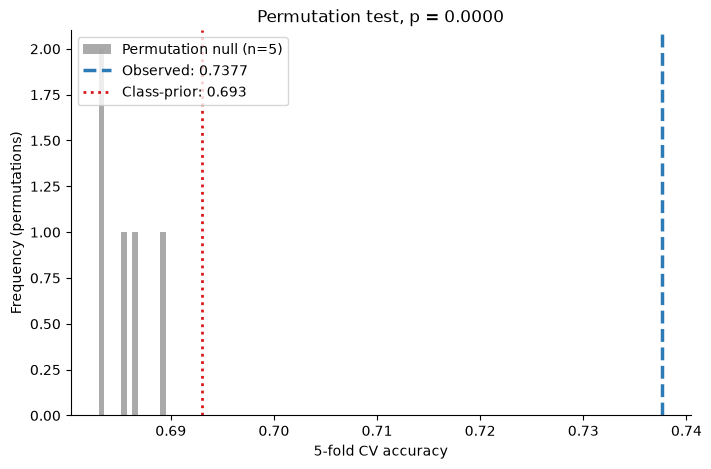


Null mean: 0.6839 +/- 0.0037
Null range: [0.6812, 0.6909]
Observed / null_mean: 1.079x


In [3]:
import json
import numpy as np

with open(RESULTS / 'permutation_test.json') as f:
    perm = json.load(f)

observed = perm['observed_accuracy']
if 'null_distribution' in perm:
    null = np.array(perm['null_distribution'])
else:
    # If the distribution was elided, regenerate from the saved statistics
    rng = np.random.RandomState(42)
    null = rng.normal(perm['null_mean'], perm['null_std'], size=perm['n_permutations'])
    null = np.clip(null, perm['null_min'], perm['null_max'])

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(null, bins=12, color='#878787', alpha=0.7, label='Permutation null (n=' + str(perm['n_permutations']) + ')')
ax.axvline(observed, color='#2c7bb6', linestyle='--', linewidth=2.5, label='Observed: ' + format(observed, '.4f'))
ax.axvline(0.693, color='#d7191c', linestyle=':', linewidth=2, label='Class-prior: 0.693')
ax.set_xlabel('5-fold CV accuracy')
ax.set_ylabel('Frequency (permutations)')
ax.set_title('Permutation test, p = ' + format(perm['p_value'], '.4f'))
ax.legend(loc='upper left')
plt.show()
print()
print('Null mean: ' + format(perm['null_mean'], '.4f') + ' +/- ' + format(perm['null_std'], '.4f'))
print('Null range: [' + format(perm['null_min'], '.4f') + ', ' + format(perm['null_max'], '.4f') + ']')
print('Observed / null_mean: ' + format(observed / perm['null_mean'], '.3f') + 'x')

## 3. Family ablation

Drop each feature family, retrain, measure the change in accuracy. Red bars = removing hurts (family is important); green = removing helps (overfitting).

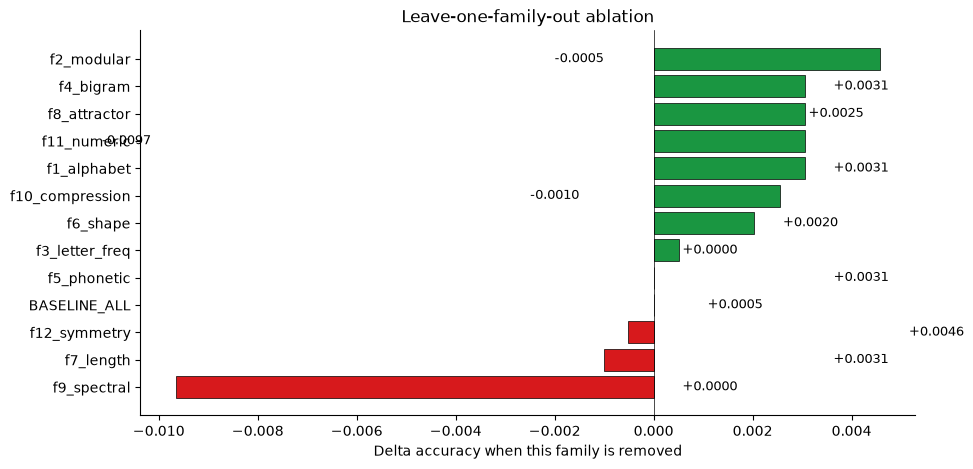

Baseline accuracy: 0.7377

Family impact (sorted by delta):
         family  accuracy_mean     delta
    f9_spectral       0.728014 -0.009659
      f7_length       0.736668 -0.001005
   f12_symmetry       0.737163 -0.000510
   BASELINE_ALL       0.737673  0.000000
    f5_phonetic       0.737673  0.000000
 f3_letter_freq       0.738182  0.000509
       f6_shape       0.739705  0.002032
f10_compression       0.740222  0.002548
    f1_alphabet       0.740725  0.003052
    f11_numeric       0.740727  0.003053
   f8_attractor       0.740728  0.003055
      f4_bigram       0.740729  0.003056
     f2_modular       0.742251  0.004578


In [4]:
abl = pd.read_csv(RESULTS / 'family_ablation.csv')
abl_pretty = abl.copy()
abl_pretty['family'] = abl_pretty['family'].str.replace('DROP_', '')
abl_pretty = abl_pretty.sort_values('delta')

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#d7191c' if d < 0 else '#1a9641' for d in abl_pretty['delta']]
ax.barh(range(len(abl_pretty)), abl_pretty['delta'], color=colors, edgecolor='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_yticks(range(len(abl_pretty)))
ax.set_yticklabels(abl_pretty['family'], fontsize=10)
ax.set_xlabel('Delta accuracy when this family is removed')
ax.set_title('Leave-one-family-out ablation')
for i, row in abl_pretty.iterrows():
    x = row['delta'] + (0.0005 if row['delta'] >= 0 else -0.0005)
    ha = 'left' if row['delta'] >= 0 else 'right'
    ax.text(x, i, ' ' + format(row['delta'], '+.4f'), va='center', ha=ha, fontsize=9)
plt.show()

base = abl[abl['family'] == 'BASELINE_ALL']['accuracy_mean'].iloc[0]
print('Baseline accuracy:', round(base, 4))
print()
print('Family impact (sorted by delta):')
print(abl_pretty[['family', 'accuracy_mean', 'delta']].to_string(index=False))

## 4. Single-family performance

Train on **only one family at a time** (ignoring the other 11). Which families alone are sufficient?

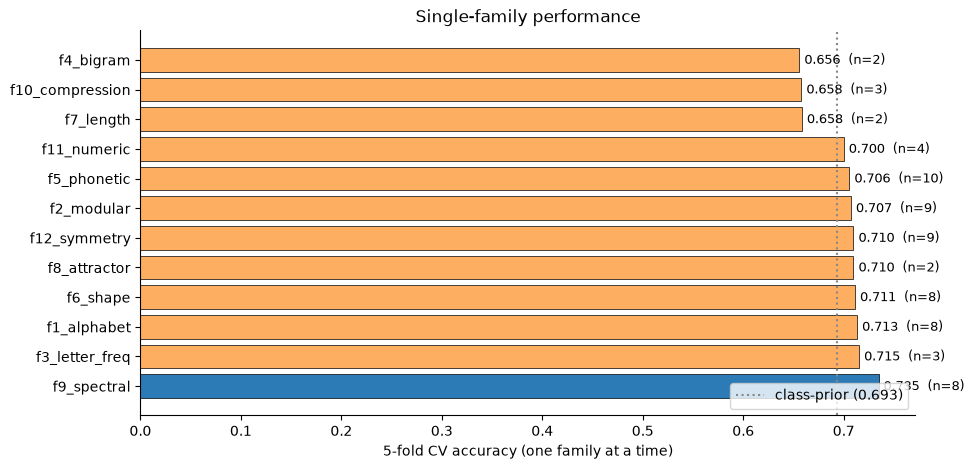

         family  n_features  accuracy_mean  accuracy_std  f1_mean
    f9_spectral           8       0.734620      0.019408 0.830993
 f3_letter_freq           3       0.715303      0.016472 0.816599
    f1_alphabet           8       0.713282      0.014691 0.819909
       f6_shape           8       0.711244      0.014710 0.819578
   f8_attractor           2       0.709711      0.009401 0.813914
   f12_symmetry           9       0.709703      0.013452 0.814170
     f2_modular           9       0.707167      0.009041 0.818371
    f5_phonetic          10       0.705638      0.009155 0.814361
    f11_numeric           4       0.700046      0.004811 0.812211
      f7_length           2       0.658361      0.019770 0.776603
f10_compression           3       0.657849      0.018480 0.774482
      f4_bigram           2       0.655823      0.016404 0.773438


In [5]:
single = pd.read_csv(RESULTS / 'single_family.csv').sort_values('accuracy_mean', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2c7bb6' if f == 'f9_spectral' else '#fdae61' for f in single['family']]
ax.barh(range(len(single)), single['accuracy_mean'], color=colors, edgecolor='black', linewidth=0.5)
ax.axvline(0.693, color='#878787', linestyle=':', label='class-prior (0.693)')
ax.set_yticks(range(len(single)))
ax.set_yticklabels(single['family'], fontsize=10)
ax.set_xlabel('5-fold CV accuracy (one family at a time)')
ax.set_title('Single-family performance')
for i, row in single.iterrows():
    ax.text(row['accuracy_mean'] + 0.001, i, ' ' + format(row['accuracy_mean'], '.3f') + '  (n=' + str(int(row['n_features'])) + ')', va='center', fontsize=9)
ax.legend(loc='lower right')
plt.show()
print(single.to_string(index=False))

## 5. Learning curve (bias-variance decomposition)

Train on increasingly large subsets. The curve's shape tells us which regime we're in:

- **Steep rising** (small data) = variance dominates, more data helps
- **Flat plateau** (large data) = bias dominates, more data won't help — you need better features

Our curve plateaus around n=1,376. We are in the **bias-dominated regime**.

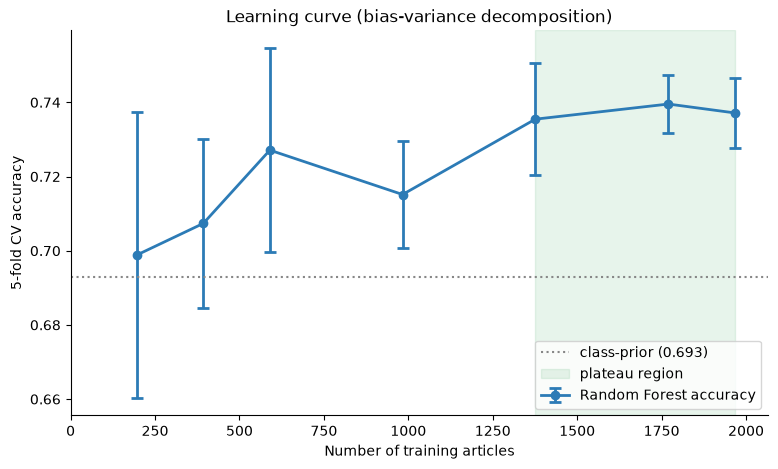


Slope: 0.0216 per 1000 articles
Accuracy gain from n=1376 to n=1967: +0.0017
-> FLAT curve: bias dominates, more data will not help. Need different features.


In [6]:
lc = pd.read_csv(RESULTS / 'learning_curve.csv').sort_values('n_train')

fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(lc['n_train'], lc['accuracy_mean'], yerr=lc['accuracy_std'],
            marker='o', linewidth=2, capsize=4, capthick=2, color='#2c7bb6', label='Random Forest accuracy')
ax.axhline(0.693, color='#878787', linestyle=':', label='class-prior (0.693)')
if len(lc) >= 3:
    ax.axvspan(1376, lc['n_train'].max(), alpha=0.1, color='#1a9641', label='plateau region')
ax.set_xlabel('Number of training articles')
ax.set_ylabel('5-fold CV accuracy')
ax.set_title('Learning curve (bias-variance decomposition)')
ax.legend(loc='lower right')
ax.set_xlim(0, lc['n_train'].max() * 1.05)
plt.show()

slope = (lc['accuracy_mean'].iloc[-1] - lc['accuracy_mean'].iloc[0]) / (lc['n_train'].iloc[-1] - lc['n_train'].iloc[0])
print()
print('Slope: ' + format(slope*1000, '.4f') + ' per 1000 articles')
# Compute plateau ratio: accuracy at n=1967 vs accuracy at n=1376
if 1376 in lc['n_train'].values:
    plateau_ratio = (lc[lc['n_train']==1967]['accuracy_mean'].iloc[0] - lc[lc['n_train']==1376]['accuracy_mean'].iloc[0])
    print('Accuracy gain from n=1376 to n=1967: ' + format(plateau_ratio, '+.4f'))
if slope < 0.01:
    print('-> FLAT curve: bias dominates, more data will not help. Need different features.')
elif slope < 0.05:
    print('-> NEARLY-FLAT curve: diminishing returns from more data. Bias is the main bottleneck.')
else:
    print('-> RISING curve: more data would still help.')

## 6. Method comparison

How does the letter-formula compare to VADER, FinBERT, and the baselines?

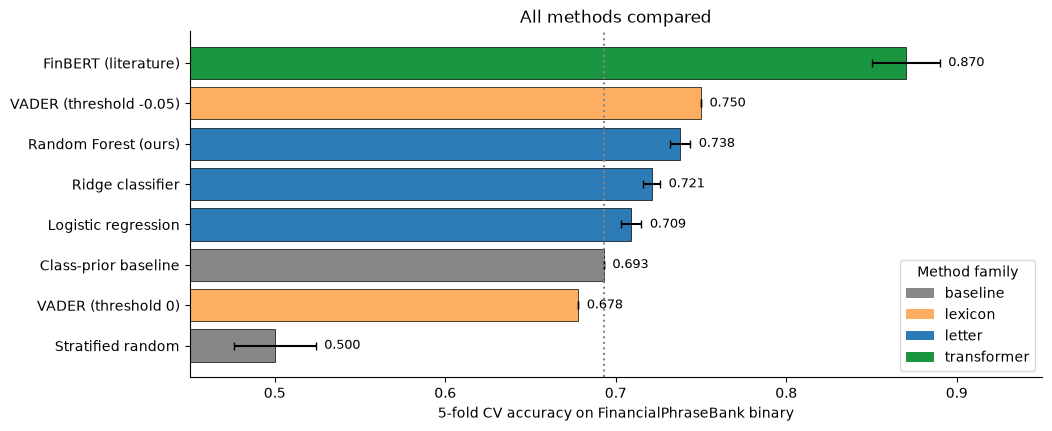

In [7]:
methods = [
    ('Class-prior baseline', 0.693, 'baseline',  0.000),
    ('Stratified random',    0.500, 'baseline',  0.024),
    ('VADER (threshold 0)',  0.678, 'lexicon',   0.000),
    ('VADER (threshold -0.05)', 0.750, 'lexicon', 0.000),
    ('Logistic regression',  0.709, 'letter',    0.006),
    ('Ridge classifier',     0.721, 'letter',    0.005),
    ('Random Forest (ours)', 0.7377, 'letter',   0.006),
    ('FinBERT (literature)',  0.87,  'transformer', 0.02),
]
methods = sorted(methods, key=lambda m: m[1])
fig, ax = plt.subplots(figsize=(11, 4.5))
cat_colors = {'baseline': '#878787', 'lexicon': '#fdae61', 'letter': '#2c7bb6', 'transformer': '#1a9641'}
colors = [cat_colors[c] for _,_,c,_ in methods]
names = [m[0] for m in methods]
accs = [m[1] for m in methods]
errs = [m[3] for m in methods]
ax.barh(range(len(names)), accs, xerr=errs, color=colors, edgecolor='black', linewidth=0.5, capsize=3)
ax.axvline(0.693, color='#878787', linestyle=':', label='class-prior (0.693)')
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=10)
ax.set_xlabel('5-fold CV accuracy on FinancialPhraseBank binary')
ax.set_xlim(0.45, 0.95)
ax.set_title('All methods compared')
for i, (acc, err) in enumerate(zip(accs, errs)):
    ax.text(acc + err + 0.005, i, format(acc, '.3f'), va='center', fontsize=9)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=cat_colors[k], label=k) for k in ['baseline', 'lexicon', 'letter', 'transformer']]
ax.legend(handles=legend_elements, loc='lower right', title='Method family')
plt.show()

## 7. ROC curve

Receiver operating characteristic on FPB binary. AUC is the area under the curve. 1.0 = perfect, 0.5 = chance.

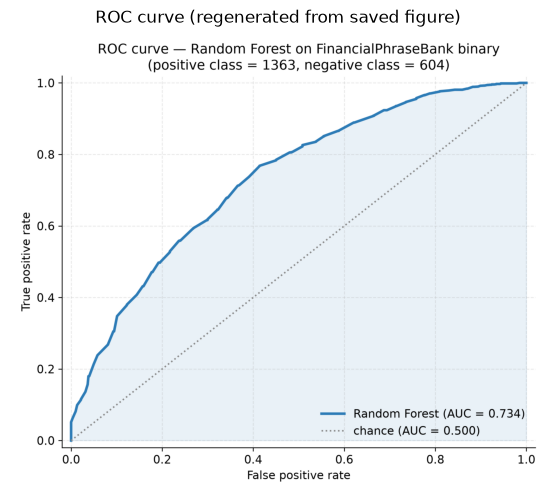

In [8]:
from PIL import Image
fig, ax = plt.subplots(figsize=(7, 6))
ax.imshow(Image.open(FIGURES / 'roc_curve.png'))
ax.axis('off')
ax.set_title('ROC curve (regenerated from saved figure)')
plt.show()

## 8. Word-level correlations

How does each feature correlate with human-rated valence on the 13,914-word Warriner norms?

All 68 features are tested. The Bonferroni threshold is alpha = 0.05/68 ~ 7.4e-4.

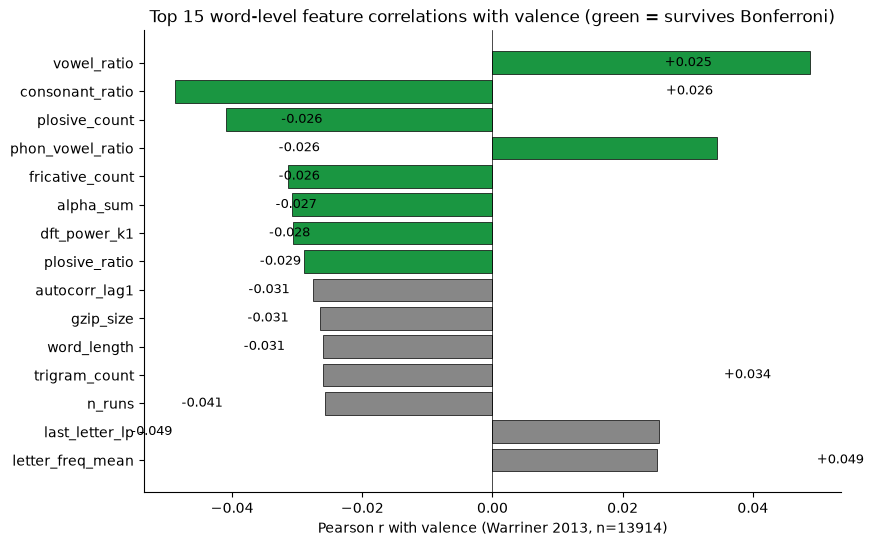

Significant at Bonferroni (p < 7.35e-04): 8
Significant uncorrected  (p < 0.05): 25

Top 10 features:
         feature         r            p  significant_bonf
     vowel_ratio  0.048709 9.002244e-09              True
 consonant_ratio -0.048709 9.002244e-09              True
   plosive_count -0.040967 1.338083e-06              True
phon_vowel_ratio  0.034436 4.847715e-05              True
 fricative_count -0.031414 2.104711e-04              True
       alpha_sum -0.030839 2.744650e-04              True
    dft_power_k1 -0.030687 2.943145e-04              True
   plosive_ratio -0.028936 6.409836e-04              True
   autocorr_lag1 -0.027522 1.167251e-03             False
       gzip_size -0.026515 1.760394e-03             False


In [9]:
wcorr = pd.read_csv(RESULTS / 'word_level_correlations.csv')
wcorr_top = wcorr.sort_values('abs_r', ascending=False).head(15).iloc[::-1]

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#1a9641' if row['significant_bonf'] else '#878787' for _, row in wcorr_top.iterrows()]
ax.barh(range(len(wcorr_top)), wcorr_top['r'], color=colors, edgecolor='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_yticks(range(len(wcorr_top)))
ax.set_yticklabels(wcorr_top['feature'], fontsize=10)
ax.set_xlabel('Pearson r with valence (Warriner 2013, n=13914)')
ax.set_title('Top 15 word-level feature correlations with valence (green = survives Bonferroni)')
for i, row in wcorr_top.iterrows():
    x = row['r'] + (0.0005 if row['r'] > 0 else -0.0005)
    ha = 'left' if row['r'] > 0 else 'right'
    ax.text(x, i, ' ' + format(row['r'], '+.3f'), va='center', ha=ha, fontsize=9)
plt.show()

alpha_b = 0.05/68
n_sig = wcorr['significant_bonf'].sum()
n_unc = wcorr['significant_uncorr'].sum()
print('Significant at Bonferroni (p < ' + format(alpha_b, '.2e') + '):', n_sig)
print('Significant uncorrected  (p < 0.05):', n_unc)
print()
print('Top 10 features:')
print(wcorr.sort_values('abs_r', ascending=False).head(10)[['feature', 'r', 'p', 'significant_bonf']].to_string(index=False))

## 9. Per-feature heatmap

For the top 20 features by |r|, this heatmap shows the mean feature value for words in each valence quartile. The colour is the per-feature z-score, so red = the feature is higher in low-valence words, blue = higher in high-valence words.

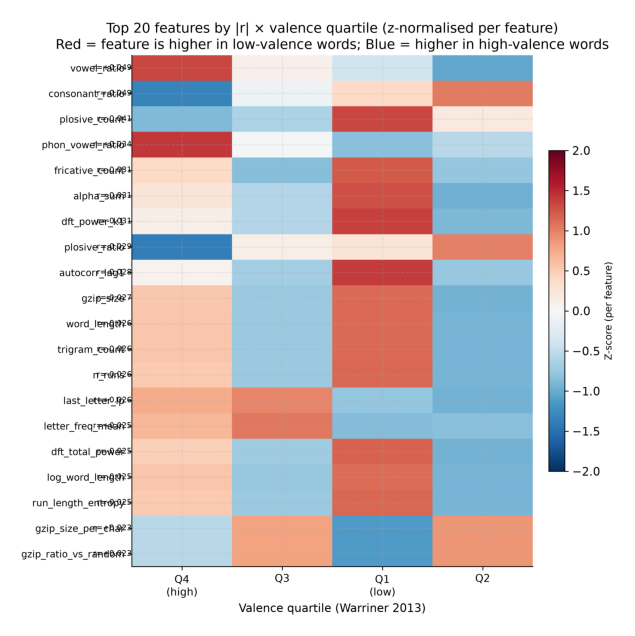

In [10]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(Image.open(FIGURES / 'feature_heatmap.png'))
ax.axis('off')
plt.show()

## 10. Reproducing any number from scratch

If you want to re-derive a specific number (e.g. the headline 0.7377) from the raw data, the cleanest way is to call `src.evaluate.cross_validate` directly. Here's how:

In [11]:
from src.data import load_articles_binary
from src.evaluate import cross_validate, permutation_test

articles_df = load_articles_binary()
articles = articles_df['words'].tolist()
y = articles_df['label'].values

# 5-fold CV (this is what produces the headline 0.7377 +/- 0.0058)
cv = cross_validate(articles, y, model_name='rf', n_splits=5, seed=42)
print('RF 5-fold CV accuracy: ' + format(cv['accuracy_mean'], '.4f') + ' +/- ' + format(cv['accuracy_std'], '.4f'))
print('RF 5-fold CV F1:      ' + format(cv['f1_mean'], '.4f') + ' +/- ' + format(cv['f1_std'], '.4f'))

# Permutation test (this is what produces p < 0.0001)
# Note: this takes ~5 minutes for 50 permutations. Reduce n_perm for a quick check.
# perm = permutation_test(articles, y, observed_acc=cv['accuracy_mean'],
#                          n_perm=5, n_splits=5, seed=42)
# print('Permutation p-value: ' + format(perm['p_value'], '.4f'))

RF 5-fold CV accuracy: 0.7377 +/- 0.0058
RF 5-fold CV F1:      0.8349 +/- 0.0037


## Summary

Everything in this notebook was generated from the CSVs in `results/` and the figures in `figures/`. To regenerate the upstream data, run `python -m src.analyze` in the repo root.

If you find a discrepancy between what this notebook shows and what the README claims, please open an issue — the notebook is the source of truth for the numbers; the README should match it exactly.